# **EDA**

In [71]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [72]:
df1 = pd.read_excel('/content/data_raw.xlsx')
print('First 5 values of dataframe \n',df1.head(5))
print('Shape of dataframe \n',df1.shape)
print('Info on dataframe \n',df1.info())
print('More info on dataframe \n',df1.describe())

First 5 values of dataframe 
   Account     ATMID' caldate     Dispense  DT  MaxCapacity  CountTotalTxn   
0     ABC  SPCN02020 2021-01-01    564500   0      2640000               157
1     ABC  TPCN10269 2021-01-01    509000   9      3520000                92
2     ABC  APCN00816 2021-01-01     64800   0      2640000                36
3     PQR   S1CN1142 2021-01-01    834500   0      3520000               101
4     PQR   S1CN2022 2021-01-01    825700   0      2860000               364
Shape of dataframe 
 (14593, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14593 entries, 0 to 14592
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           14593 non-null  object        
 1   ATMID'            14593 non-null  object        
 2   caldate           14593 non-null  datetime64[ns]
 3   Dispense          14593 non-null  int64         
 4   DT                14593 non-null  int64

In [73]:
# Separate the header row from the data rows
# The original df already has correctly identified column names.
# df.iloc[0] contains the first row of data, which the user intends to treat as a header for re-combining.
conceptual_header_row = df1.iloc[0]
data_rows_to_sort = df1.iloc[1:].copy()

# Sort alphabetically (A-Z) by 'Account' first, and then by "ATMID'"
# Using sort_values keeps the entire row intact, preserving all other column mappings
df = data_rows_to_sort.sort_values(by=['Account', "ATMID'"], ascending=True)

# Recombine the conceptual header row with the sorted data rows
# When creating a DataFrame from conceptual_header_row, use df.columns for proper column alignment.
df = pd.concat([pd.DataFrame([conceptual_header_row], columns=df.columns), df], ignore_index=True)

# Display the first few rows of the sorted result
print(df.head(6))

  Account     ATMID' caldate     Dispense    DT  MaxCapacity  CountTotalTxn   
0     ABC  SPCN02020 2021-01-01    564500     0      2640000               157
1     ABC  APAN11109 2021-01-01    106500    13      3520000                56
2     ABC  APAN11109 2021-01-02    112500   829      3520000                51
3     ABC  APAN11109 2021-01-03         0  1440      3520000                12
4     ABC  APAN11109 2021-01-04    149000  1064      3520000                53
5     ABC  APAN11109 2021-01-05    531000   133      3520000               156


In [74]:
print('First 5 values of sorted dataframe\n',df.head(5))
print('Shape of sorted dataframe \n',df.shape)
print('Info on sorted dataframe \n',df.info())
print('More info on sorted dataframe \n',df.describe())

First 5 values of sorted dataframe
   Account     ATMID' caldate     Dispense    DT  MaxCapacity  CountTotalTxn   
0     ABC  SPCN02020 2021-01-01    564500     0      2640000               157
1     ABC  APAN11109 2021-01-01    106500    13      3520000                56
2     ABC  APAN11109 2021-01-02    112500   829      3520000                51
3     ABC  APAN11109 2021-01-03         0  1440      3520000                12
4     ABC  APAN11109 2021-01-04    149000  1064      3520000                53
Shape of sorted dataframe 
 (14593, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14593 entries, 0 to 14592
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           14593 non-null  object        
 1   ATMID'            14593 non-null  object        
 2   caldate           14593 non-null  datetime64[ns]
 3   Dispense          14593 non-null  int64         
 4   DT            

In [75]:
print('misssing values:',df.isnull().sum())
#display(df.isnull().sum())
#sns.heatmap(df.isnull(), cbar=False)
print('duplicate values:',df.duplicated().sum())

misssing values: Account             0
ATMID'              0
caldate             0
Dispense            0
DT                  0
MaxCapacity         0
CountTotalTxn       0
dtype: int64
duplicate values: 0


In [76]:
#fixing column names

df.columns = df.columns.str.strip()
print('Cleaned Column Names:', df.columns)
df = df.rename(columns={'ATMID\'': 'ATMID'})
print(df.columns)

Cleaned Column Names: Index(['Account', 'ATMID'', 'caldate', 'Dispense', 'DT', 'MaxCapacity',
       'CountTotalTxn'],
      dtype='object')
Index(['Account', 'ATMID', 'caldate', 'Dispense', 'DT', 'MaxCapacity',
       'CountTotalTxn'],
      dtype='object')


In [77]:
df["caldate"].min()
df["caldate"].max()
df["Account"].value_counts()

,count
Account,
ABC,5481
PQR,5201
XYZ,3911


<Axes: xlabel='Dispense', ylabel='Count'>

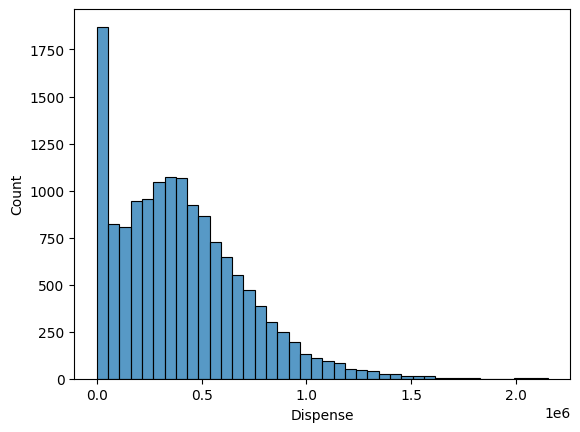

In [78]:
sns.histplot(df["Dispense"], bins=40)

<Axes: xlabel='Account', ylabel='Dispense'>

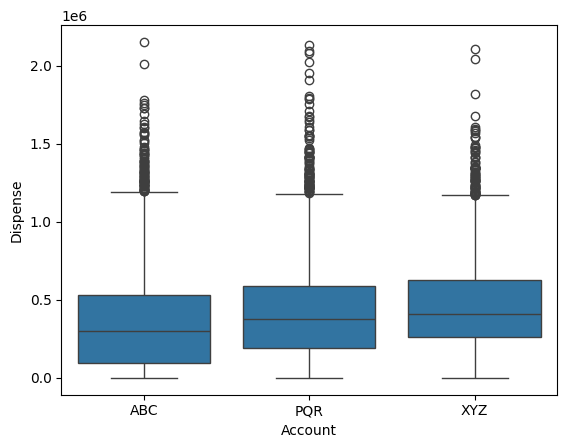

In [79]:
sns.boxplot(
    x="Account",
    y="Dispense",
    data=df
)

In [80]:
atm_avg = (
    df.groupby("ATMID")["Dispense"]
      .mean()
      .sort_values()
)
print(atm_avg)

ATMID
APAN35706         85967.688378
APCN00816        105902.681992
S1CN2011         149522.664016
S1CN1142         256857.982120
T1BH000003039    257538.775510
T1BH000274012    295402.117264
APAN11109        298731.800766
SPCNG376         299547.892720
T1BH000603091    328507.269790
S1CN2820         375154.916986
APAN22403        401063.984674
SPCN02020        402062.196679
T1NH000575414    467214.309484
S1CN3514         474553.639847
APAN23217        476889.399745
T1BH000011116    536735.007849
T1BH007252090    545651.941748
SPCND067         590157.088123
T1NY000166081    626145.083014
S1CN2022         671004.469987
TPCN10269        692686.206897
Name: Dispense, dtype: float64


<Axes: xlabel='CountTotalTxn', ylabel='Count'>

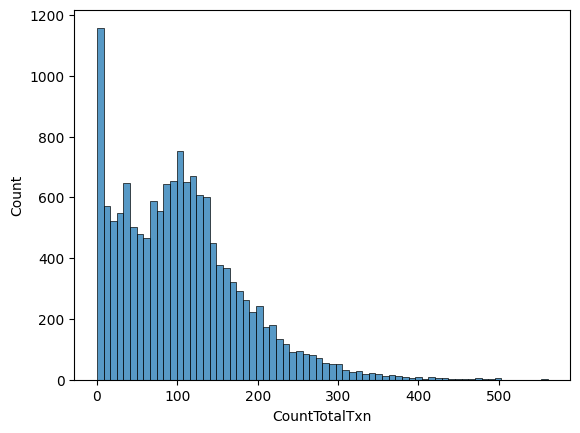

In [81]:
sns.histplot(df["CountTotalTxn"])

<Axes: >

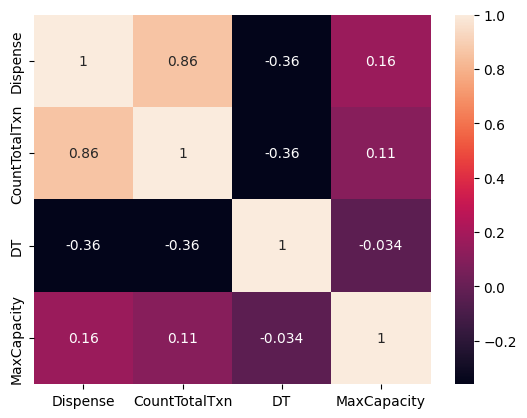

In [82]:
corr = df[["Dispense", "CountTotalTxn", "DT", "MaxCapacity"]].corr()
sns.heatmap(corr, annot=True)

<Axes: xlabel='DT', ylabel='Dispense'>

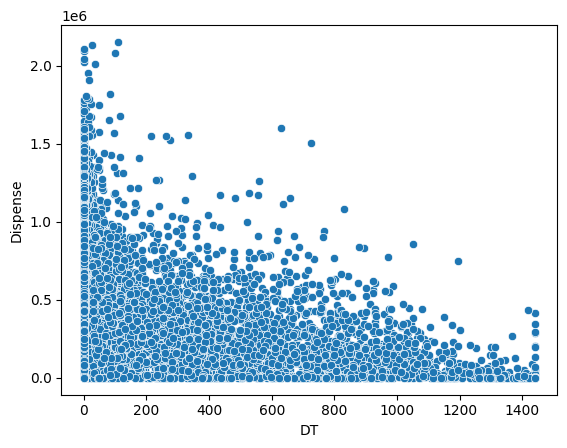

In [83]:
sns.scatterplot(x="DT", y="Dispense", data=df)

In [84]:
df["CapacityUtilization"] = (df["Dispense"] /df["MaxCapacity"])

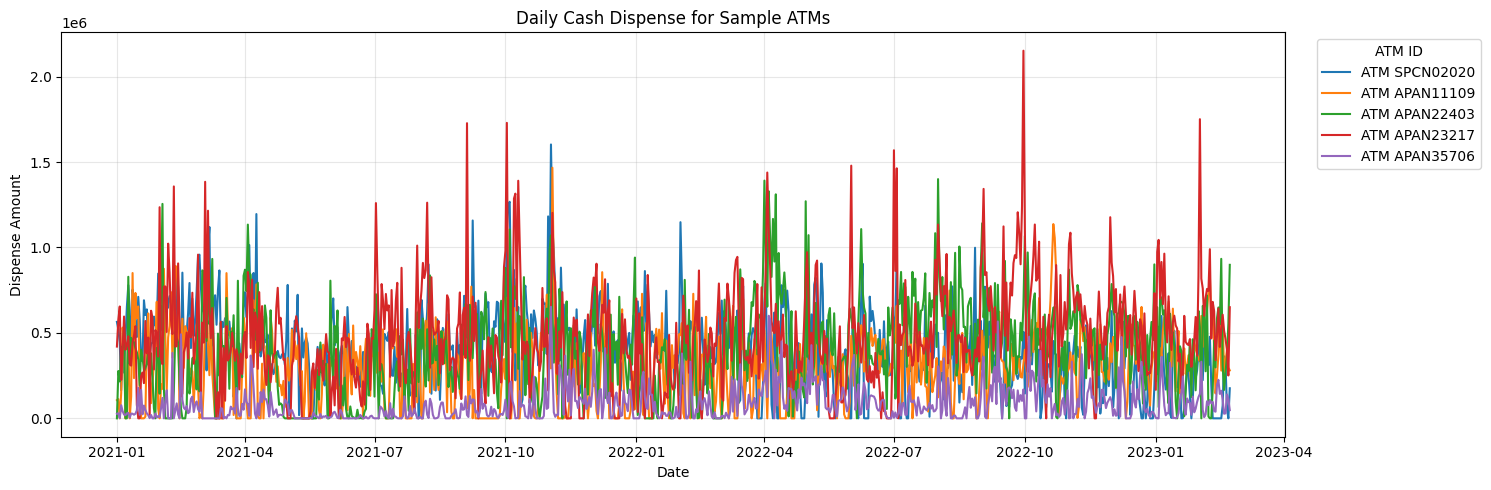

In [85]:
# Select a few sample ATMs
sample_atms = df["ATMID"].unique()[:5]   # First 5 ATMs

plt.figure(figsize=(15, 5))

for atm in sample_atms:
    atm_data = df[df["ATMID"] == atm].sort_values("caldate")

    plt.plot(
        atm_data["caldate"],
        atm_data["Dispense"],
        label=f"ATM {atm}",
        linewidth=1.5
    )

plt.title("Daily Cash Dispense for Sample ATMs")
plt.xlabel("Date")
plt.ylabel("Dispense Amount")
plt.legend(title="ATM ID", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

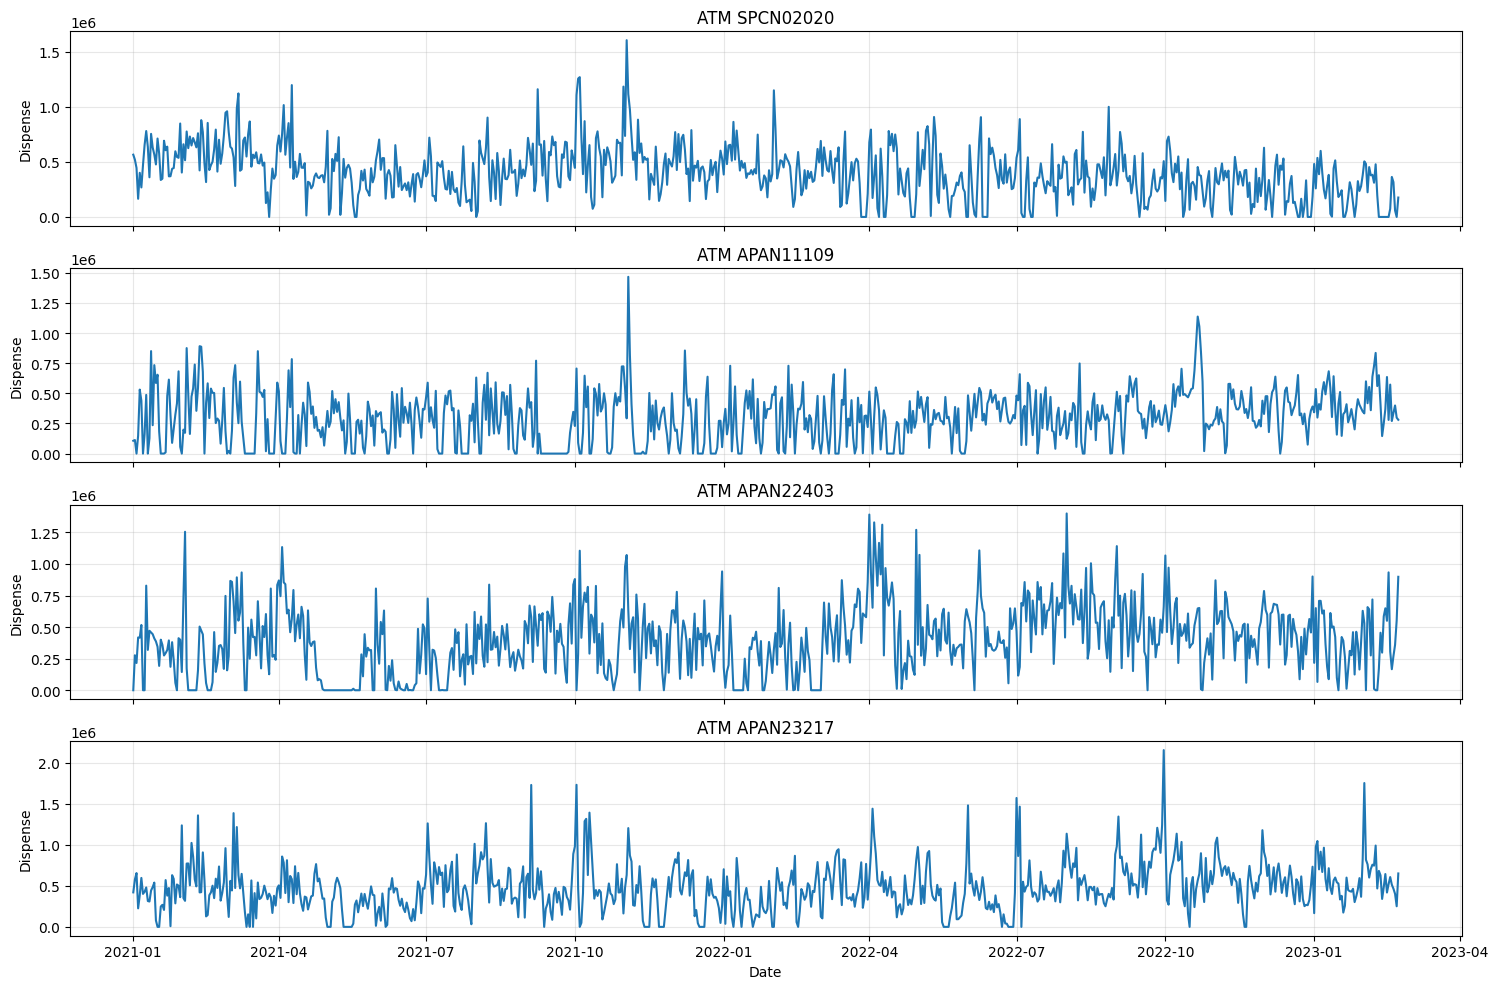

In [86]:
sample_atms = df["ATMID"].unique()[:4]

fig, axes = plt.subplots(len(sample_atms), 1, figsize=(15, 10), sharex=True)

for ax, atm in zip(axes, sample_atms):
    atm_data = df[df["ATMID"] == atm].sort_values("caldate")

    ax.plot(atm_data["caldate"], atm_data["Dispense"], linewidth=1.5)
    ax.set_title(f"ATM {atm}")
    ax.set_ylabel("Dispense")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

# **Feature Engg**

In [87]:
#Calendar Features
# Calendar features
df["Year"] = df["caldate"].dt.year
df["Month"] = df["caldate"].dt.month
df["Day"] = df["caldate"].dt.day
df["Quarter"] = df["caldate"].dt.quarter
df["Week"] = df["caldate"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["caldate"].dt.dayofweek          # Monday=0
df["DayOfYear"] = df["caldate"].dt.dayofyear

# Weekend flag
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

# Month boundaries
df["IsMonthStart"] = df["caldate"].dt.is_month_start.astype(int)
df["IsMonthEnd"] = df["caldate"].dt.is_month_end.astype(int)

In [88]:
#Lags
lags = [1, 2, 3, 7, 14, 21, 28]

for lag in lags:
    df[f"Lag_{lag}"] = (
        df.groupby("ATMID")["Dispense"]
          .shift(lag)
    )
df["Dispense"].shift(7)

,Dispense
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
14588,469800.0
14589,843700.0
14590,269300.0
14591,526300.0


In [89]:
#rolling mean
windows = [3, 7, 14, 30]

for window in windows:
    df[f"RollingMean_{window}"] = (
        df.groupby("ATMID")["Dispense"]
          .transform(lambda x: x.shift(1).rolling(window).mean())
    )

In [90]:
#rolling std

for window in [7, 14, 30]:
    df[f"RollingStd_{window}"] = (
        df.groupby("ATMID")["Dispense"]
          .transform(lambda x: x.shift(1).rolling(window).std())
    )

In [91]:
#exponential MA

for span in [7, 14]:
    df[f"EMA_{span}"] = (
        df.groupby("ATMID")["Dispense"]
          .transform(lambda x: x.shift(1).ewm(span=span).mean())
    )

In [92]:
# growth features

df["DispenseDiff"] = (
    df.groupby("ATMID")["Dispense"]
      .diff()
)

df["DispensePctChange"] = (
    df.groupby("ATMID")["Dispense"]
      .pct_change()
)

In [93]:
# transaction features

df["AvgDispensePerTxn"] = (
    df["Dispense"] /
    df["CountTotalTxn"]
)

df["TxnPerDispense"] = (
    df["CountTotalTxn"] /
    df["Dispense"]
)

df["AvgDispensePerTxn"] = np.where(
    df["CountTotalTxn"] == 0,
    0,
    df["Dispense"] / df["CountTotalTxn"]
)

df["TxnPerDispense"] = np.where(
    df["Dispense"] == 0,
    0,
    df["CountTotalTxn"] / df["Dispense"]
)

In [94]:
#Downtime Features
df["DownFlag"] = (df["DT"] > 0).astype(int)
df["DowntimeHours"] = df["DT"] / 60

In [95]:
#Capacity Features
df["CapacityUtilization"] = (df["Dispense"]/df["MaxCapacity"])
df["RemainingCapacity"] = (df["MaxCapacity"]-df["Dispense"])

# **Data Prep**

In [96]:
df_model = df.dropna().copy()
print(df_model.shape)

(13431, 41)


In [97]:
df_model.isnull().sum()

,0
Account,0
ATMID,0
caldate,0
Dispense,0
DT,0
MaxCapacity,0
CountTotalTxn,0
CapacityUtilization,0
Year,0
Month,0


In [98]:
from sklearn.preprocessing import LabelEncoder

le_bank = LabelEncoder()
le_atm = LabelEncoder()

df_model["Account"] = le_bank.fit_transform(df_model["Account"])
df_model["ATMID"] = le_atm.fit_transform(df_model["ATMID"])

## Split data

In [99]:
train = df_model[df_model["caldate"] < "2023-02-15"]

test = df_model[df_model["caldate"] >= "2023-02-15"]

In [100]:
train

,Account,ATMID,caldate,Dispense,DT,MaxCapacity,CountTotalTxn,CapacityUtilization,Year,Month,...,RollingStd_30,EMA_7,EMA_14,DispenseDiff,DispensePctChange,AvgDispensePerTxn,TxnPerDispense,DownFlag,DowntimeHours,RemainingCapacity
31,0,0,2021-01-31,0,0,3520000,17,0.000000,2021,1,...,261970.573938,313391.182409,306620.542038,-56000.0,-1.000000,0.000000,0.000000,0,0.000000,3520000
32,0,0,2021-02-01,199000,0,3520000,43,0.056534,2021,2,...,265178.095111,235032.891766,265247.879498,199000.0,inf,4627.906977,0.000216,0,0.000000,3321000
33,0,0,2021-02-02,172500,0,3520000,30,0.049006,2021,2,...,263741.472597,226023.763836,256323.236840,-26500.0,-0.133166,5750.000000,0.000174,0,0.000000,3347500
34,0,0,2021-02-03,875500,13,3520000,203,0.248722,2021,2,...,259164.189847,212641.814690,245046.504938,703000.0,4.075362,4312.807882,0.000232,1,0.216667,2644500
35,0,0,2021-02-04,489000,0,3520000,157,0.138920,2021,2,...,278709.586009,378365.725162,329759.986766,-386500.0,-0.441462,3114.649682,0.000321,0,0.000000,3031000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14580,2,19,2023-02-10,543400,0,3520000,158,0.154375,2023,2,...,173491.827791,473812.261123,414509.105849,-38800.0,-0.066644,3439.240506,0.000291,0,0.000000,2976600
14581,2,19,2023-02-11,469800,0,3520000,124,0.133466,2023,2,...,177232.071674,491209.195842,431694.558402,-73600.0,-0.135444,3788.709677,0.000264,0,0.000000,3050200
14582,2,19,2023-02-12,843700,0,3520000,207,0.239687,2023,2,...,178480.707641,485856.896882,436775.283949,373900.0,0.795871,4075.845411,0.000245,0,0.000000,2676300
14583,2,19,2023-02-13,269300,0,3520000,114,0.076506,2023,2,...,198776.305394,575317.672661,491031.912755,-574400.0,-0.680811,2362.280702,0.000423,0,0.000000,3250700


In [101]:
#baseline = test["Lag_1"]

In [102]:
features = [
    "ATMID",
    "Account",
    "CountTotalTxn",
    "DT",
    "MaxCapacity",
    "CapacityUtilization",
    "Year",
    "Month",
    "Day",
    "Quarter",
    "Week",
    "DayOfWeek",
    "DayOfYear",
    "IsWeekend",
    "IsMonthStart",
    "IsMonthEnd",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_7",
    "Lag_14",
    "Lag_21",
    "Lag_28",
    "RollingMean_3",
    "RollingMean_7",
    "RollingMean_14",
    "RollingMean_30",
    "RollingStd_7",
    "RollingStd_14",
    "RollingStd_30",
    "EMA_7",
    "EMA_14",
    "DispenseDiff",
    "DispensePctChange",
    "AvgDispensePerTxn",
    "TxnPerDispense",
    "DownFlag",
    "DowntimeHours",
    "RemainingCapacity"
]

target = "Dispense"

In [103]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [104]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_pred = test["Lag_1"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE : 140623.41772151898
Baseline RMSE: 191705.33444107536


In [106]:
from xgboost import XGBRegressor

# Replace infinite values with NaN and then fill NaN with 0
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [107]:
predictions = model.predict(X_test)

In [108]:
print(predictions)

[ 6.34504562e+05  2.79806000e+05  5.72032375e+05  2.71450031e+05
  3.37691219e+05  3.99054406e+05  2.98839625e+05  2.79820031e+05
  5.47022438e+05  9.29665062e+05  3.07241531e+05  1.65655016e+05
  2.71300531e+05  3.56096781e+05  5.53409812e+05  8.95699000e+05
  4.17277125e+05  5.20962156e+05  6.07868312e+05  5.13033312e+05
  4.65132844e+05  4.02504188e+05  2.51451734e+05  6.50804500e+05
  1.45027750e+05  1.62495797e+05  1.10262570e+05  2.77552617e+04
  2.80638848e+04  1.39897281e+05  1.13908500e+05  4.80789336e+04
  1.77060828e+05  6.92049922e+04  4.86765781e+04  7.50524141e+04
  4.95593848e+03  1.39967312e+05  1.18644820e+05  9.53260625e+04
  7.50592500e+04  3.62047906e+05  3.14481406e+05  5.71645781e+04
 -1.57465029e+01  1.77003719e+05  7.17171562e+05  6.44478625e+05
  4.40484906e+05  4.07103719e+05  5.13278500e+05  6.34370875e+05
  6.48642438e+05  5.27136062e+05  2.00406281e+05  4.33149805e+04
  2.11088398e+04  1.03314469e+05  9.64862266e+04  8.42543906e+04
  1.17189258e+05  8.11579

In [109]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Model MAE :", mae)
print("Model RMSE:", rmse)

Model MAE : 1018.1288452148438
Model RMSE: 1306.6067216266722


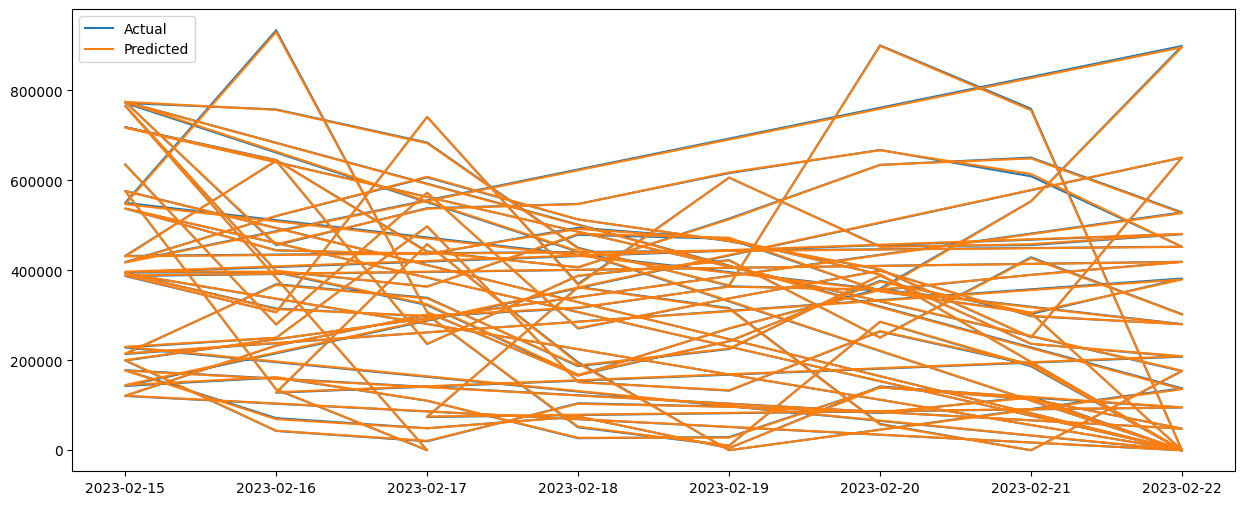

In [110]:
comparison = test.copy()

comparison["Actual"] = y_test
comparison["Predicted"] = predictions

plt.figure(figsize=(15,6))

plt.plot(comparison["caldate"], comparison["Actual"], label="Actual")
plt.plot(comparison["caldate"], comparison["Predicted"], label="Predicted")

plt.legend()
plt.show()

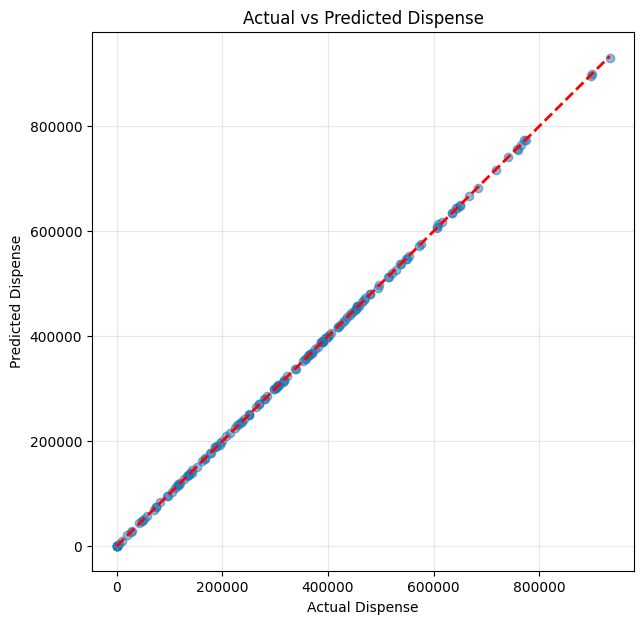

In [115]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Dispense")
plt.ylabel("Predicted Dispense")
plt.title("Actual vs Predicted Dispense")
plt.grid(alpha=0.3)

plt.show()

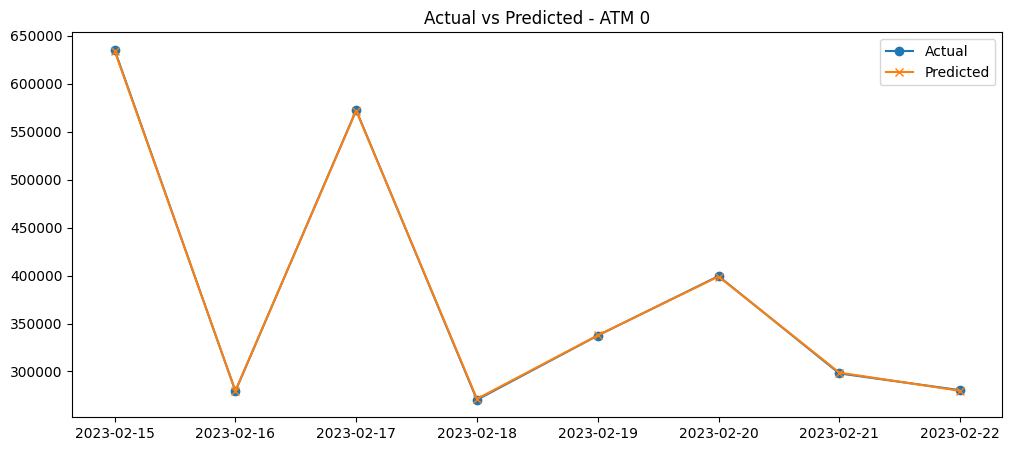

In [111]:
atm = comparison["ATMID"].iloc[0]

atm_df = comparison[comparison["ATMID"] == atm]

plt.figure(figsize=(12,5))
plt.plot(atm_df["caldate"], atm_df["Actual"], marker='o', label="Actual")
plt.plot(atm_df["caldate"], atm_df["Predicted"], marker='x', label="Predicted")
plt.title(f"Actual vs Predicted - ATM {atm}")
plt.legend()
plt.show()

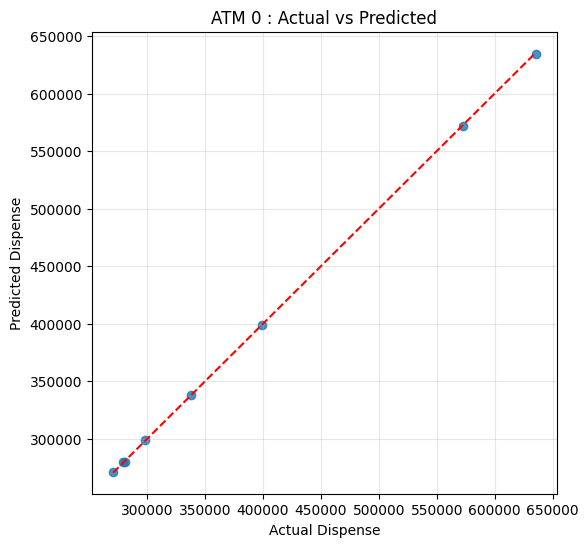

In [116]:
plt.figure(figsize=(6,6))

plt.scatter(
    atm_df["Actual"],
    atm_df["Predicted"],
    alpha=0.8
)

plt.plot(
    [atm_df["Actual"].min(), atm_df["Actual"].max()],
    [atm_df["Actual"].min(), atm_df["Actual"].max()],
    'r--'
)

plt.xlabel("Actual Dispense")
plt.ylabel("Predicted Dispense")
plt.title(f"ATM {atm} : Actual vs Predicted")

plt.grid(alpha=0.3)
plt.show()

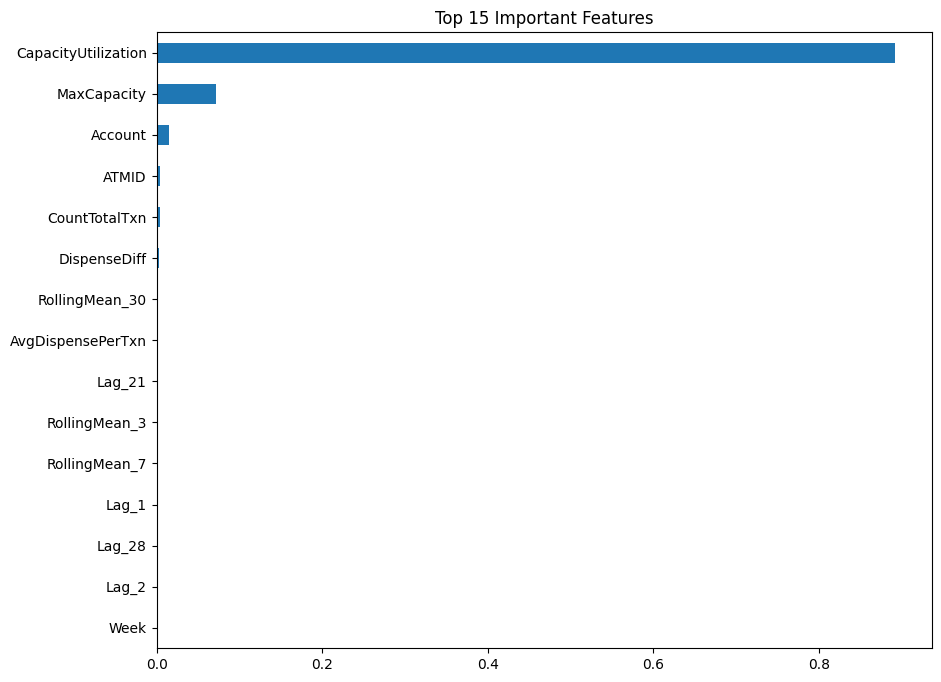

In [112]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Important Features")
plt.show()

In [113]:
forecast = test[["Account", "ATMID", "caldate"]].copy()

forecast["Actual"] = y_test.values
forecast["Forecast"] = predictions

forecast.head()

,Account,ATMID,caldate,Actual,Forecast
776,0,0,2023-02-15,635500,634504.56250
777,0,0,2023-02-16,279500,279806.00000
778,0,0,2023-02-17,572500,572032.37500
779,0,0,2023-02-18,270500,271450.03125
780,0,0,2023-02-19,337500,337691.21875


In [114]:
forecast.to_csv("forecast.csv", index=False)